In [1]:
import glob
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
import os

import scanpy as sc
import seaborn as sns

from scroutines import basicu
from scroutines import powerplots

import warnings
from statsmodels.tools.sm_exceptions import ConvergenceWarning
from statsmodels.tools.sm_exceptions import ValueWarning
from tqdm import tqdm

sns.set_context('talk')

In [2]:
outfigdir = '/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/results_v1astro'

In [3]:
f = '/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/annot/gencode.vM25.genebody.bed'
df_annot = pd.read_csv(f, sep='\t', header=None)
df_annot

,0,1,2,3
0,chr1,3073253,3074322,4933401J01Rik
1,chr1,3102016,3102125,Gm26206
2,chr1,3205901,3671498,Xkr4
3,chr1,3252757,3253236,Gm18956
4,chr1,3365731,3368549,Gm37180
...,...,...,...,...
55396,chrM,13552,14070,mt-Nd6
55397,chrM,14071,14139,mt-Te
55398,chrM,14145,15288,mt-Cytb
55399,chrM,15289,15355,mt-Tt


In [4]:
!ls $outfigdir

astro_cheng_subtypes_260128.csv
NRDR_DEGs_LMM_astro_cheng22_d260129_c1.h5ad
NRDR_DEGs_LMM_astro_cheng22_d260129.h5ad
NRDR_DEGs_LMM_astro_cheng22_d260210_Astro_A.h5ad
NRDR_DEGs_LMM_astro_cheng22_d260210_Astro_B.h5ad
NRDR_DEGs_LMM_yoo25_P21_d260303_L23.csv
NRDR_DEGs_LMM_yoo25_P21_d260303_L4.csv
NRDR_DEGs_LMM_yoo25_P21_d260303_L5IT.csv
NRDR_DEGs_LMM_yoo25_P21_d260303_L6IT.csv


In [5]:
sex_genes = ['Xist', 'Kdm5d','Eif2s3y','Uty','Ddx3y']

In [6]:
track_labels = ['L2/3', 'L4', 'L5IT', 'L6IT']

filenames = [
    os.path.join(outfigdir, 'NRDR_DEGs_LMM_yoo25_P21_d260303_L23.csv'),
    os.path.join(outfigdir, 'NRDR_DEGs_LMM_yoo25_P21_d260303_L4.csv'),
    os.path.join(outfigdir, 'NRDR_DEGs_LMM_yoo25_P21_d260303_L5IT.csv'),
    os.path.join(outfigdir, 'NRDR_DEGs_LMM_yoo25_P21_d260303_L6IT.csv'),
]

res_list = []
for filename in filenames:
    res = pd.read_csv(filename, index_col=0)
    res = res[~res['gene'].str.startswith('mt-')]
    res = res[~res['gene'].isin(sex_genes)]
    res = res.set_index('gene')
    res_list.append(res)
    
res_list[0]


,log2fc,pval,qval,converged,P21DRa,P21DRb,P21a,P21b
gene,,,,,,,,
Xkr4,0.110382,0.525454,0.999981,True,6.756924,7.221993,6.527616,6.385153
Gm1992,-0.442290,0.153152,0.628909,True,0.118180,0.177694,0.220761,0.180830
Mrpl15,0.293080,0.388635,0.917568,True,0.183829,0.189502,0.142200,0.159951
Tcea1,0.020396,0.828567,0.999981,False,0.574420,0.564013,0.537349,0.589466
Rgs20,-0.071648,0.334967,0.875696,True,1.263996,1.223394,1.123293,1.525580
...,...,...,...,...,...,...,...,...
Csf2ra,-0.302227,0.004842,0.077457,True,0.205204,0.221681,0.225591,0.310990
Vamp7,0.144694,0.903655,0.999981,True,0.099579,0.117071,0.072693,0.124550
Tmlhe,0.134706,0.960626,0.999981,True,0.205323,0.221628,0.184059,0.203766


In [7]:
df_list = []
df_sig_list = []
df_raw_list = []
idx = 2

x_th =  np.log2(1.5)
y_th = -np.log10(0.05)

q_inf = 1e-50
# z = df['max_cp10k']
# z_th = 0.1

for i, res in enumerate(res_list):
    
    
    df = res.copy()
    df['l2fc'] = res['log2fc']#[:,idx]
    df['l10q'] = -np.log10(res['qval'])#[:,idx])
    
    # converge, expressed (or not too small q)
    cond_pre = np.logical_and(res['converged'], 
                              res['qval']>q_inf)
    df_raw = df.copy()
    df = df[cond_pre]

    x = df['l2fc'].values 
    y = df['l10q'].values
    z = df['score'] = np.abs(df['l2fc']).rank(pct=True)+df['l10q'].rank(pct=True)
    
    cond_sig = np.all([np.abs(x) > x_th, 
                       y > y_th, 
                       # z > z_th, 
                      ], axis=0)

    print(np.sum(cond_sig))
    df_sig = df[cond_sig]
    df_sig = df_sig.sort_values('l10q', ascending=False)
    df_sig['direction'] = np.where(df_sig['l2fc']>0, 'up', 'down')
    
    df_list.append(df)
    df_sig_list.append(df_sig)
    df_raw_list.append(df_raw)


149
215
173
3


/u/home/f/f7xiesnm/.conda/envs/napari/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/u/home/f/f7xiesnm/.conda/envs/napari/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)
/u/home/f/f7xiesnm/.conda/envs/napari/lib/python3.9/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


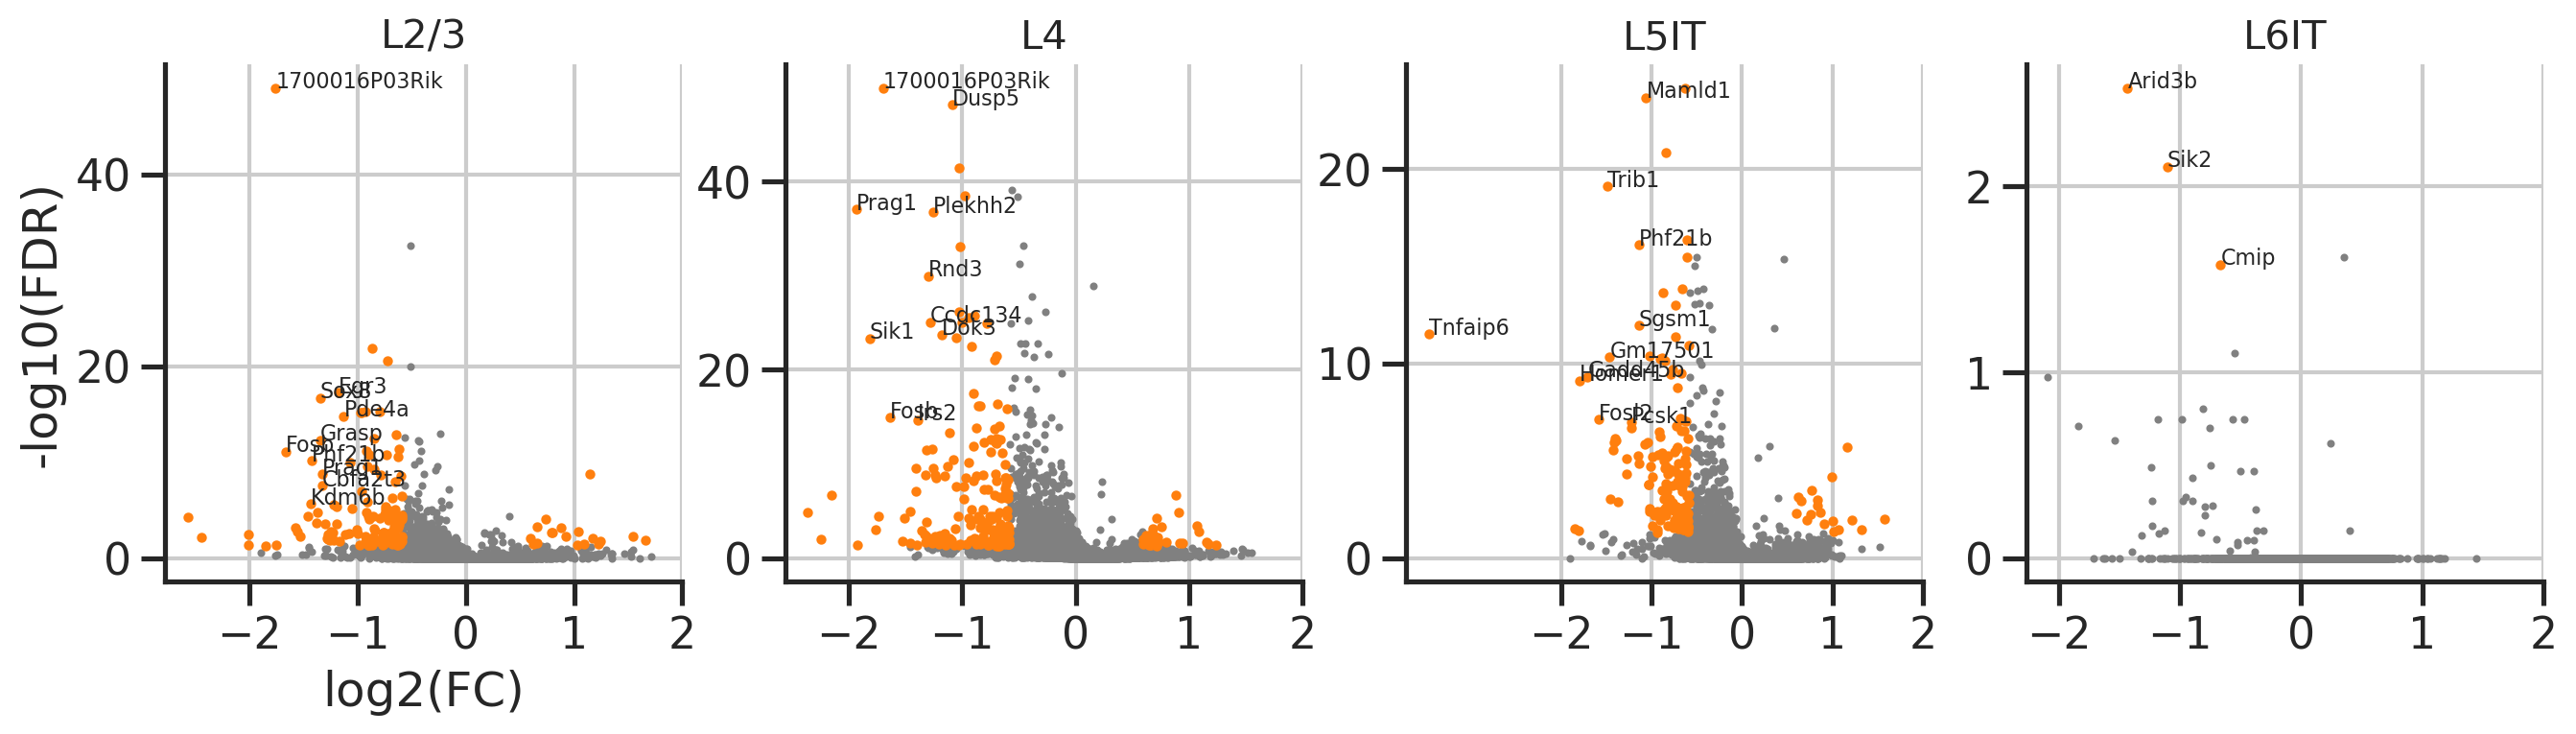

In [8]:

fig, axs = plt.subplots(1,4,figsize=(4*4,1*3.5)) # , sharey=True)
for i in range(4):
    ax = axs[i]
    df = df_list[i]
    df_sig = df_sig_list[i]
    title = track_labels[i]

    ax.scatter(df['l2fc'].values, df['l10q'].values, s=2, color='gray')
    ax.scatter(df_sig['l2fc'].values, df_sig['l10q'].values, s=5, color='C1')
    for gene, row in df_sig.sort_values('score', ascending=False).head(10).iterrows():
        x = row['l2fc']
        y = row['l10q']
        ax.text(x,y,gene, fontsize=8)
    sns.despine(ax=ax)
    ax.set_title(title, fontsize=15)
    ax.set_xticks([-2,-1,0,1,2])
    
axs[0].set_xlabel('log2(FC)')
axs[0].set_ylabel('-log10(FDR)')
plt.show()

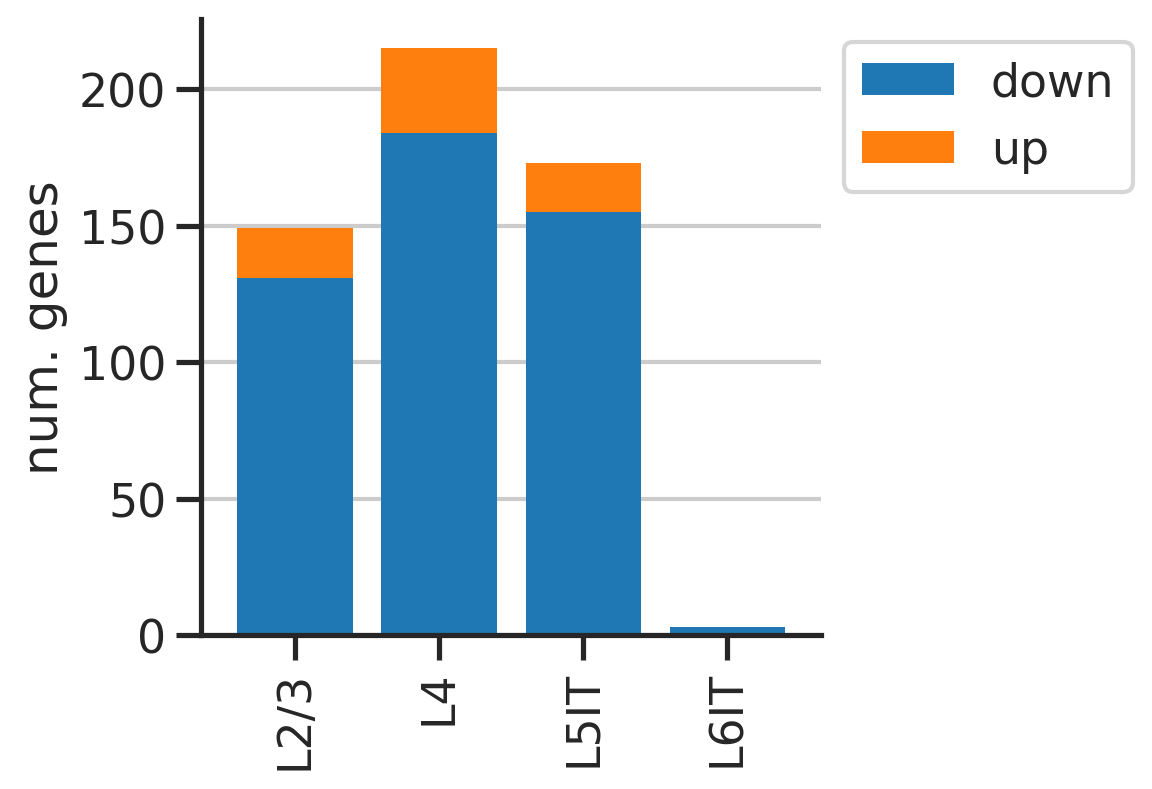

In [9]:

nums_sig = []
for i in range(4):
    df_sig = df_sig_list[i]
    # df_sig.groupby()plot.bar()
    nums_sig.append(df_sig.groupby('direction').size()) # .plot.bar()
    
nums_sig = pd.concat(nums_sig, axis=1).fillna(0) #names=track_labels)
fig, ax = plt.subplots(figsize=(4,4))
nums_sig.T.plot.bar(stacked=True, edgecolor='none', width=0.8, ax=ax)
sns.despine(ax=ax)
ax.set_xticklabels(track_labels)
ax.legend(bbox_to_anchor=(1,1))
ax.grid(axis='x')
ax.set_ylabel('num. genes')
plt.show()


In [10]:
for res in res_list:
    print(res.loc['Arid3b'])#['P21a', 'P21b', 'P21DRa', 'P21DRb'])

log2fc      -1.280829
pval         0.000228
qval          0.00782
converged        True
P21DRa       0.282356
P21DRb       0.279172
P21a         0.792213
P21b         0.585006
Name: Arid3b, dtype: object
log2fc       -1.32068
pval         0.002192
qval         0.021767
converged        True
P21DRa       0.278431
P21DRb       0.257774
P21a         0.795927
P21b         0.558284
Name: Arid3b, dtype: object
log2fc       -0.98618
pval         0.001062
qval         0.021364
converged        True
P21DRa       0.211952
P21DRb       0.167175
P21a          0.43078
P21b         0.336512
Name: Arid3b, dtype: object
log2fc      -1.434102
pval         0.000002
qval         0.002967
converged        True
P21DRa       0.362643
P21DRb       0.358663
P21a         1.069631
P21b         0.850607
Name: Arid3b, dtype: object


# cell level data

In [11]:
import time

adata = sc.read("/u/home/f/f7xiesnm/project-zipursky/v1-bb/v1/data/v1_multiome/superdupermegaRNA_hasraw_multiome_P21NRDR.h5ad")
ti = time.time()
adata.X = adata.raw.X
print(time.time()-ti)
print(adata.X.data)
adata

0.07771086692810059
[35.  2.  1. ...  3.  8.  1.]


AnnData object with n_obs × n_vars = 31039 × 16572
    obs: 'Age', 'Doublet', 'Doublet Score', 'n_counts', 'n_genes', 'percent_mito', 'sample', 'Type', 'Subclass', 'Class', 'Sample', 'total_counts', 'pct_counts_mt', 'n_genes_by_counts', 'total_counts_mt', 'Doublet?', 'Study', 'Type_leiden'
    var: 'feature_types'

In [12]:
# remove mitocondria genes
adata = adata[:,~adata.var.index.str.contains(r'^mt-')]

# remove sex genes
sex_genes = ["Xist", "Uty", "Eif2s3y", "Kdm5d", "Ddx3y"]
adata = adata[:,[g for g in adata.var.index if g not in sex_genes]]

# filter genes
cond = np.ravel((adata.X>0).sum(axis=0)) > 10 # expressed in more than 10 cells
adata = adata[:,cond].copy()
# genes = adata.var.index.values

adata

AnnData object with n_obs × n_vars = 31039 × 16547
    obs: 'Age', 'Doublet', 'Doublet Score', 'n_counts', 'n_genes', 'percent_mito', 'sample', 'Type', 'Subclass', 'Class', 'Sample', 'total_counts', 'pct_counts_mt', 'n_genes_by_counts', 'total_counts_mt', 'Doublet?', 'Study', 'Type_leiden'
    var: 'feature_types'

In [13]:
offset = 1e-2
scale = 1e4

mat = np.array(adata.X.todense())/adata.obs['total_counts'].values.reshape(-1,1)*scale
adata.layers['cp10k'] = mat
adata.layers['log2cp10k'] = np.log2(1+mat)
adata

AnnData object with n_obs × n_vars = 31039 × 16547
    obs: 'Age', 'Doublet', 'Doublet Score', 'n_counts', 'n_genes', 'percent_mito', 'sample', 'Type', 'Subclass', 'Class', 'Sample', 'total_counts', 'pct_counts_mt', 'n_genes_by_counts', 'total_counts_mt', 'Doublet?', 'Study', 'Type_leiden'
    var: 'feature_types'
    layers: 'cp10k', 'log2cp10k'

In [14]:
sample_orders = adata.obs['Sample'].astype(str).unique()
print(sample_orders)

palette = {
    'P21': 'C1', 
    'P21DR': 'gray', 
    }

['P21a' 'P21b' 'P21DRa' 'P21DRb']


In [15]:
def plot_one_gene_ax(gene, ax, adata, df_stats):
    """
    """
    dfplot = adata.obs[['Age', 'Sample', 'Subclass']].copy()
    dfplot[gene] = np.array(adata[:,gene].layers['log2cp10k']).reshape(-1,)
    stats = df_stats.loc[gene]

    sns.violinplot(data=dfplot, x='Sample', hue='Age', palette=palette,
                   order=sample_orders, 
                   dodge=False, y=gene, 
                   cut=0, 
                   ax=ax)
    ax.set_title(f'{gene}')

    ax.text(0.05, 0.95, f'q={np.power(10, -stats.l10q):.2g}, l2fc={stats.l2fc:.2g}, conv {stats.converged}', 
            ha='left',
            transform=ax.transAxes, 
            fontsize=12)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=90, fontsize=12)
    ax.set_xlabel('')
    ax.set_ylabel('log2(1+cp10k)', fontsize=12)
    sns.despine(ax=ax)
    return dfplot

In [16]:
adata_list = []
for track_label in track_labels:
    adata_subclass = adata[adata.obs['Subclass']==track_label]
    adata_list.append(adata_subclass)

In [17]:
df_raw_list[0]

,log2fc,pval,qval,converged,P21DRa,P21DRb,P21a,P21b,l2fc,l10q
gene,,,,,,,,,,
Xkr4,0.110382,0.525454,0.999981,True,6.756924,7.221993,6.527616,6.385153,0.110382,0.000008
Gm1992,-0.442290,0.153152,0.628909,True,0.118180,0.177694,0.220761,0.180830,-0.442290,0.201412
Mrpl15,0.293080,0.388635,0.917568,True,0.183829,0.189502,0.142200,0.159951,0.293080,0.037362
Tcea1,0.020396,0.828567,0.999981,False,0.574420,0.564013,0.537349,0.589466,0.020396,0.000008
Rgs20,-0.071648,0.334967,0.875696,True,1.263996,1.223394,1.123293,1.525580,-0.071648,0.057646
...,...,...,...,...,...,...,...,...,...,...
Csf2ra,-0.302227,0.004842,0.077457,True,0.205204,0.221681,0.225591,0.310990,-0.302227,1.110937
Vamp7,0.144694,0.903655,0.999981,True,0.099579,0.117071,0.072693,0.124550,0.144694,0.000008
Tmlhe,0.134706,0.960626,0.999981,True,0.205323,0.221628,0.184059,0.203766,0.134706,0.000008


In [18]:
adata_list[2]

View of AnnData object with n_obs × n_vars = 1211 × 16547
    obs: 'Age', 'Doublet', 'Doublet Score', 'n_counts', 'n_genes', 'percent_mito', 'sample', 'Type', 'Subclass', 'Class', 'Sample', 'total_counts', 'pct_counts_mt', 'n_genes_by_counts', 'total_counts_mt', 'Doublet?', 'Study', 'Type_leiden'
    var: 'feature_types'
    layers: 'cp10k', 'log2cp10k'

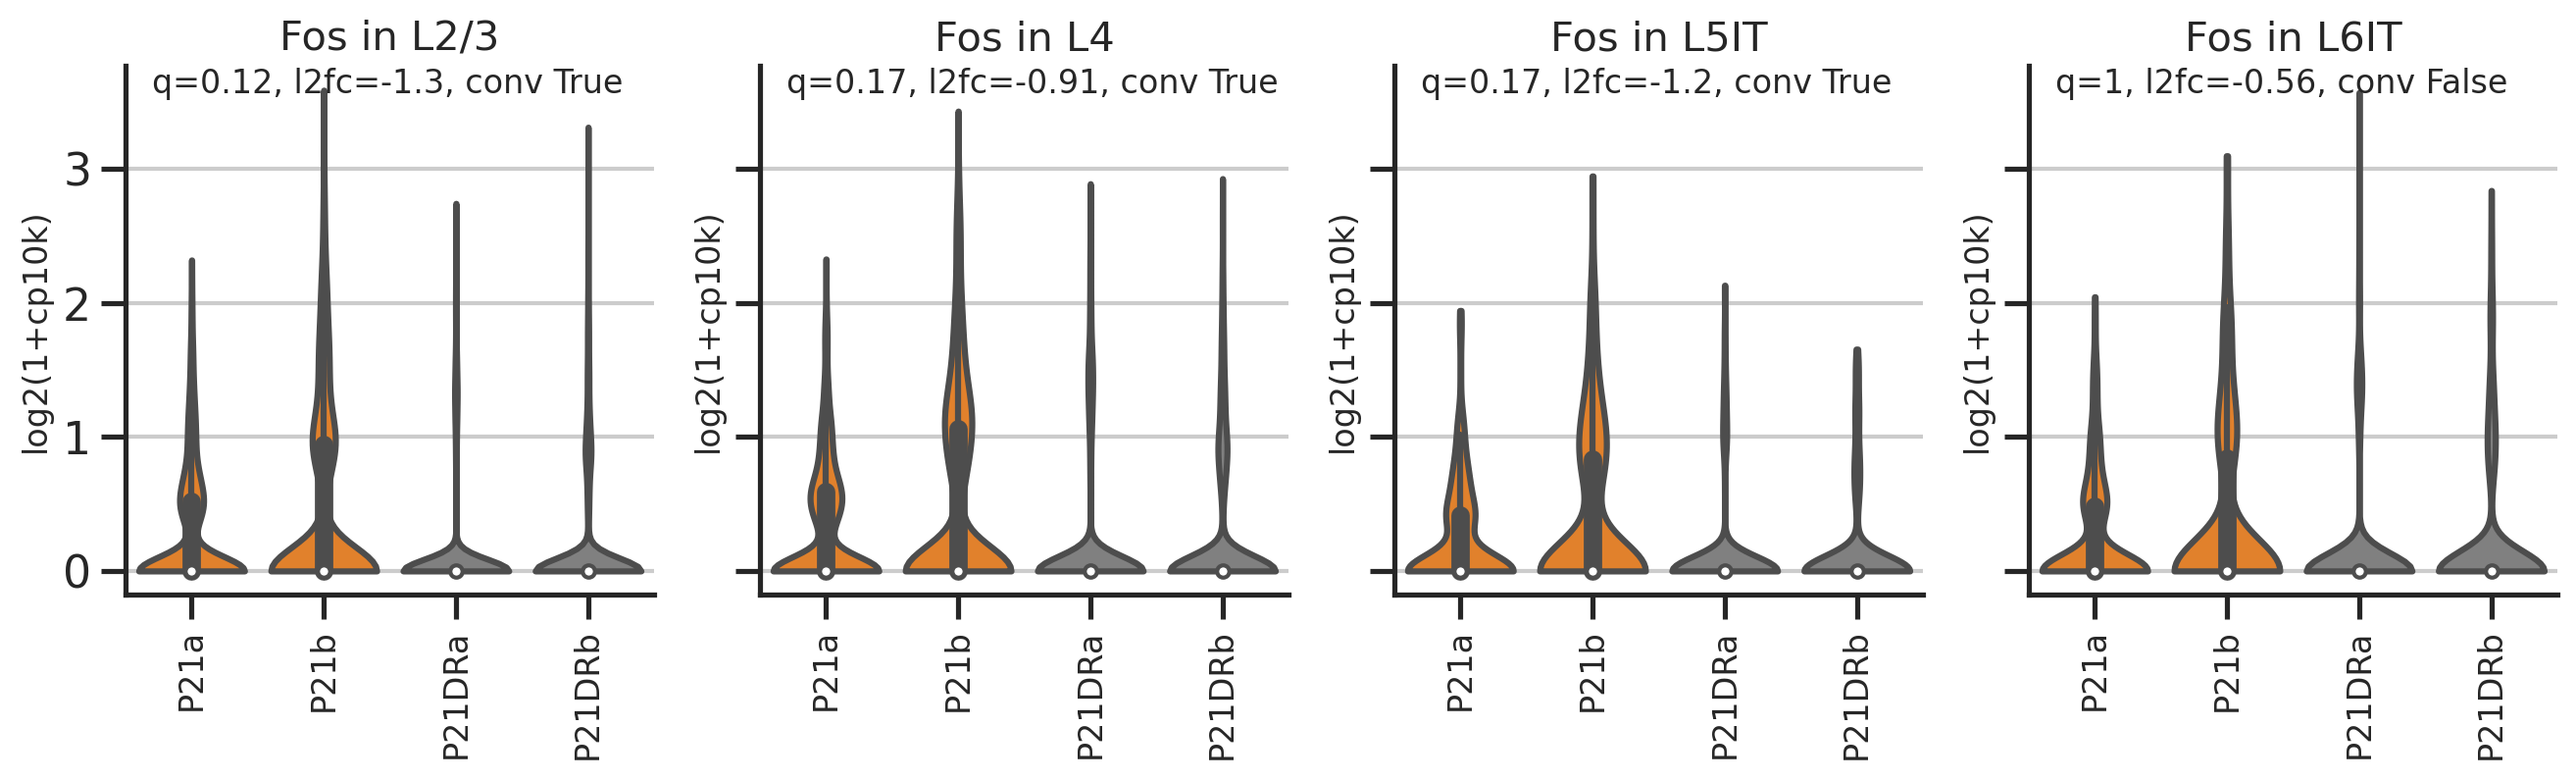

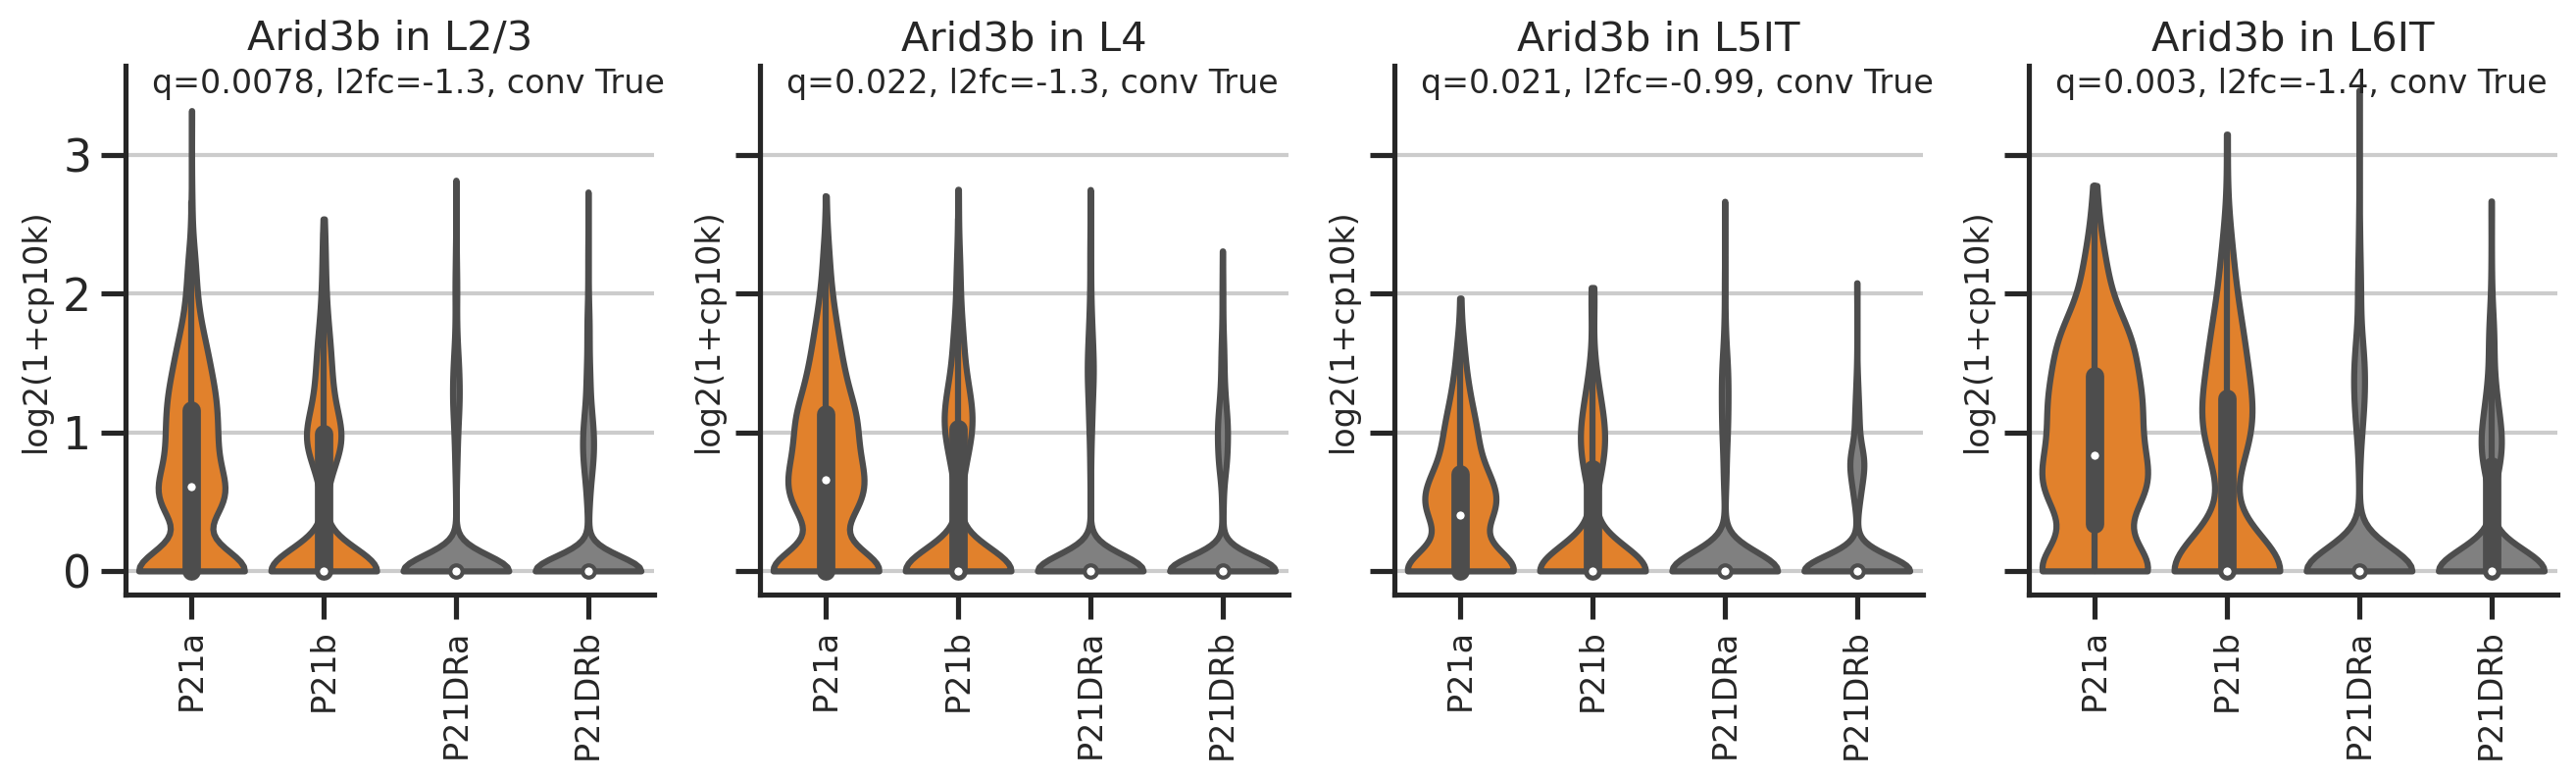

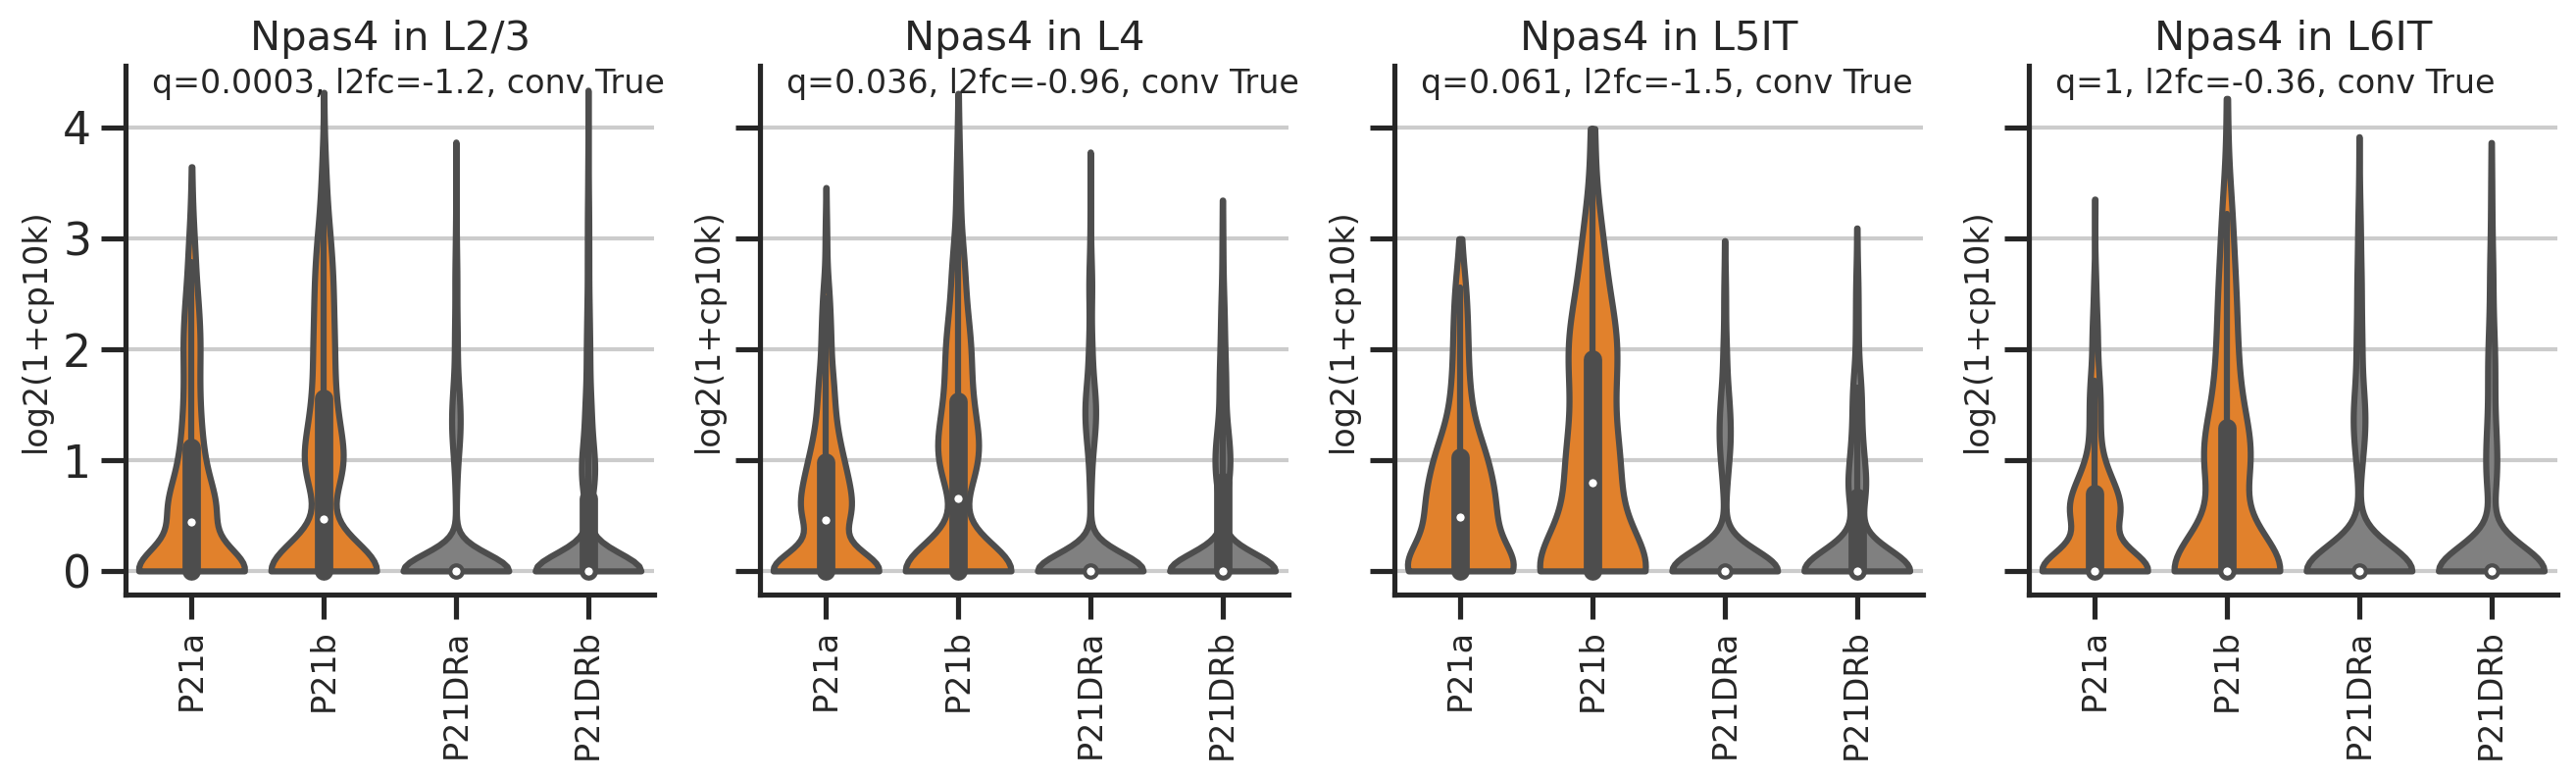

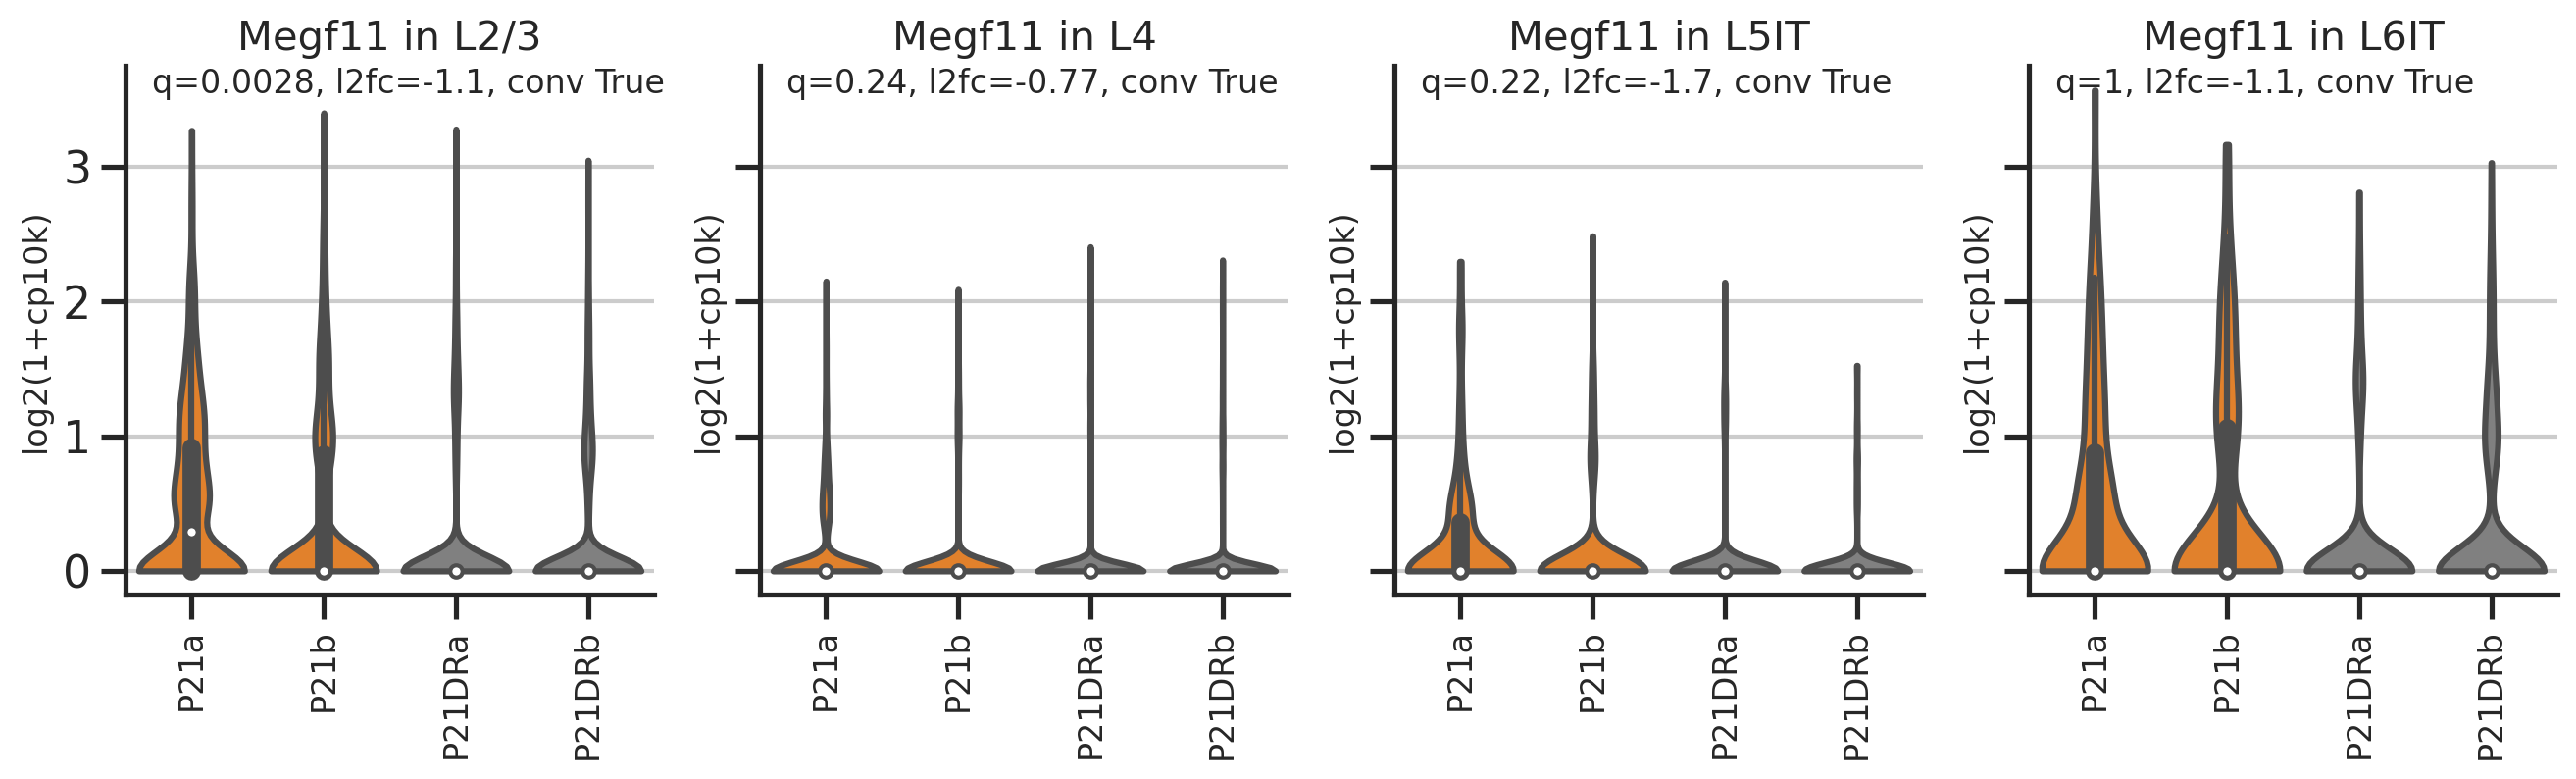

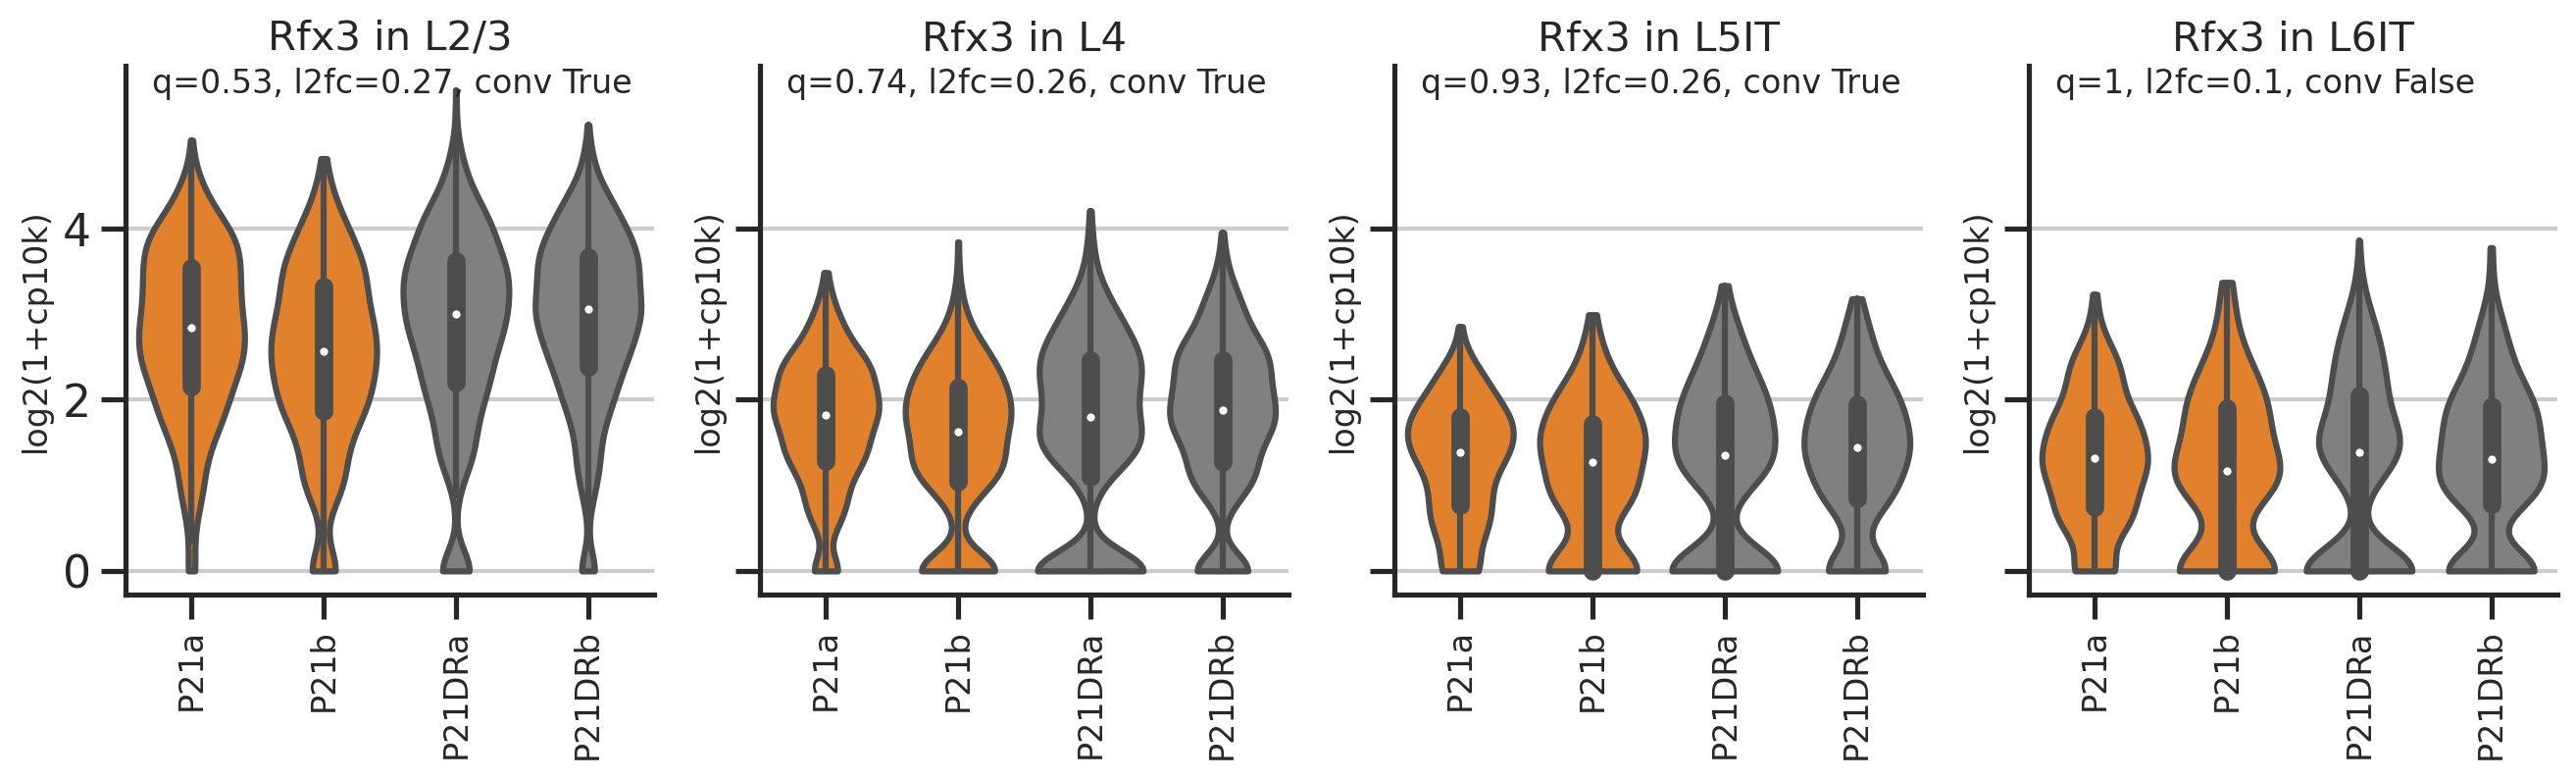

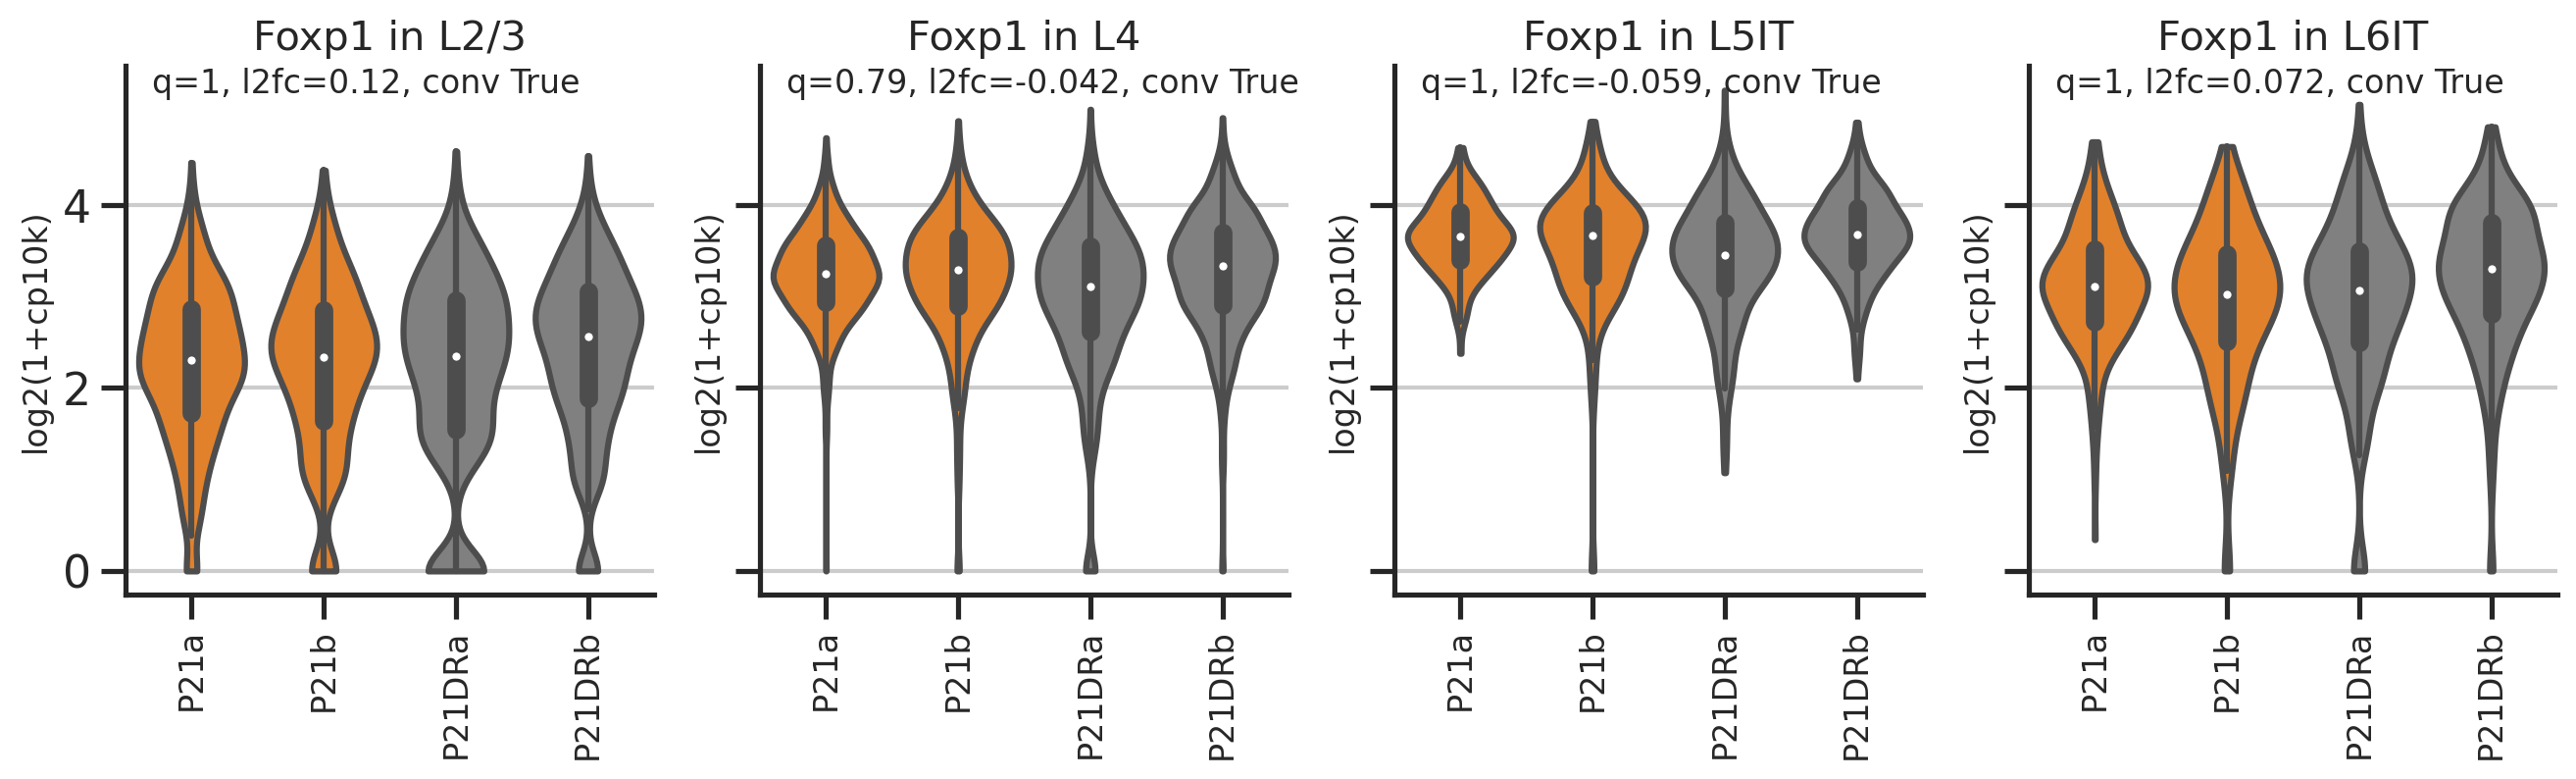

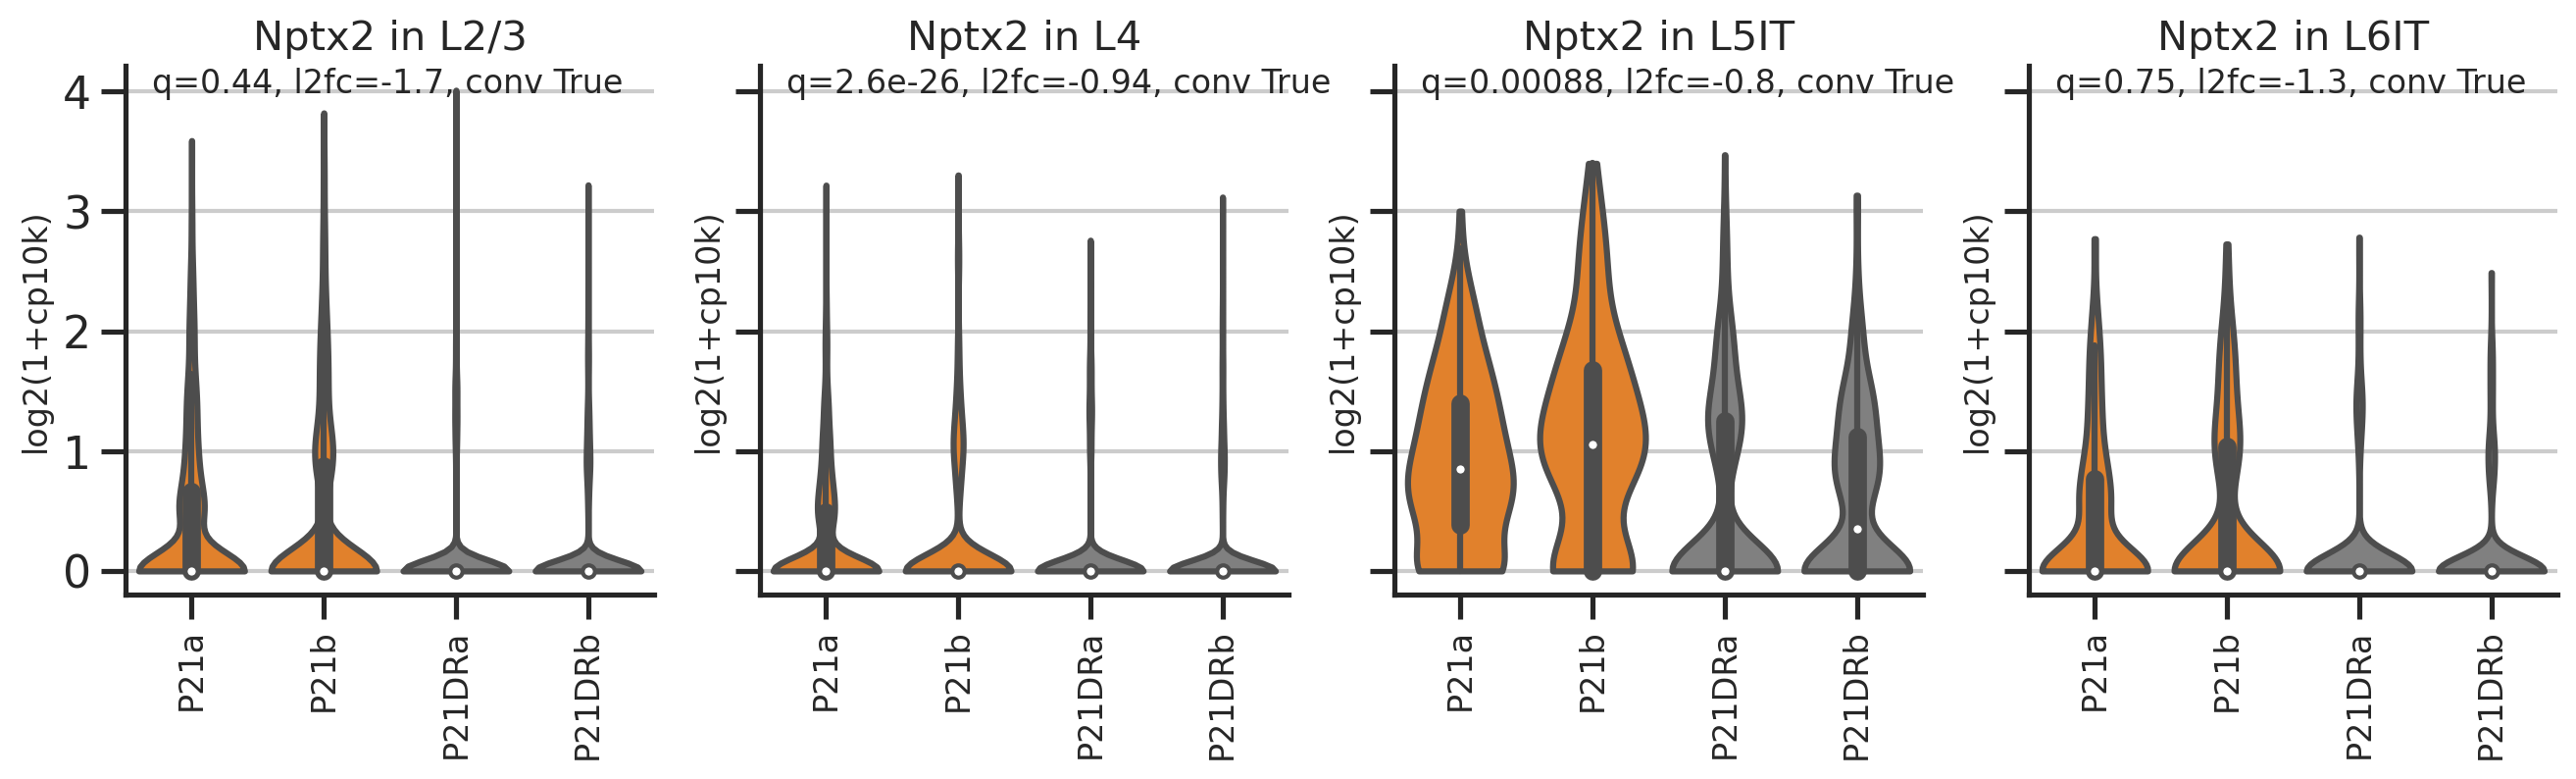

In [20]:
for gene in ['Fos', 'Arid3b', 'Npas4', 'Megf11', 'Rfx3', 'Foxp1', 'Nptx2']:
    fig, axs = plt.subplots(1, 4, figsize=(16,3.5), sharey=True, sharex=True)
    for i in range(4):
        ax = axs[i]
        df = df_raw_list[i]
        adata_subclass = adata_list[i]
        track_label = track_labels[i]
        
        dfplot = plot_one_gene_ax(gene, ax, adata_subclass, df)
        ax.set_title(f'{gene} in {track_label}', fontsize=15)
        ax.legend_.remove()

    plt.show()

# shared vs different